# 3. Exploratory Data Analysis

This section is focused on exploring the SQL Generator No CoT dataset to understand its characteristics before modelling. We look into:
- Prompt
- SQL Lenghts
- SQL Keyword distributions
- Query Complexity
- Data Quality

## 3.1 Setup & Data Loading

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

### 3.1.1 Load Dataset and Extract Question + SQL

In [35]:
# Load cleaned dataset aftern Section 2
df = pd.read_csv("../data/processed.csv")

print(f"Loaded {len(df):,} rows from processed.csv")
print(f"Columns: {list(df.columns)}")
df.head(3)

Loaded 9,198 rows from processed.csv
Columns: ['prompt', 'question', 'response', 'sql']


,prompt,question,response,sql
0,"You are a data science expert.\nBelow, you are...",How many teachers have made some type of donat...,```sql\nSELECT COUNT(DISTINCT T2.teacher_accti...,SELECT COUNT(DISTINCT T2.teacher_acctid) FROM ...
1,"You are a data science expert.\nBelow, you are...",Please list the full names of any three countr...,```sql\nSELECT DISTINCT T2.LongName FROM Count...,SELECT DISTINCT T2.LongName FROM CountryNotes ...
2,"You are a data science expert.\nBelow, you are...",Of all the All-star players who played in the ...,```sql\nSELECT COUNT(DISTINCT T1.playerID) FRO...,SELECT COUNT(DISTINCT T1.playerID) FROM player...


## 3.2 Length Analysis

Measuring lengths in both characters and tokens for questions and SQL queries.

In [36]:
df['prompt_char_len']    = df['prompt'].str.len()
df['question_char_len']  = df['question'].str.len()
df['question_word_len']  = df['question'].str.split().str.len()
df['sql_char_len']       = df['sql'].str.len()
df['sql_token_len']      = df['sql'].str.split().str.len()

length_stats = df[['prompt_char_len', 'question_char_len', 'question_word_len',
                    'sql_char_len', 'sql_token_len']].describe().round(1)
length_stats

,prompt_char_len,question_char_len,question_word_len,sql_char_len,sql_token_len
count,9198.0,9198.0,9198.0,9198.0,9198.0
mean,1439.6,79.8,14.1,172.4,26.9
std,323.4,30.2,5.3,75.5,11.6
min,724.0,24.0,4.0,25.0,5.0
25%,1218.0,58.0,10.0,126.0,20.0
50%,1398.0,75.0,13.0,164.0,25.0
75%,1609.0,95.0,17.0,211.0,33.0
max,4758.0,325.0,59.0,806.0,141.0


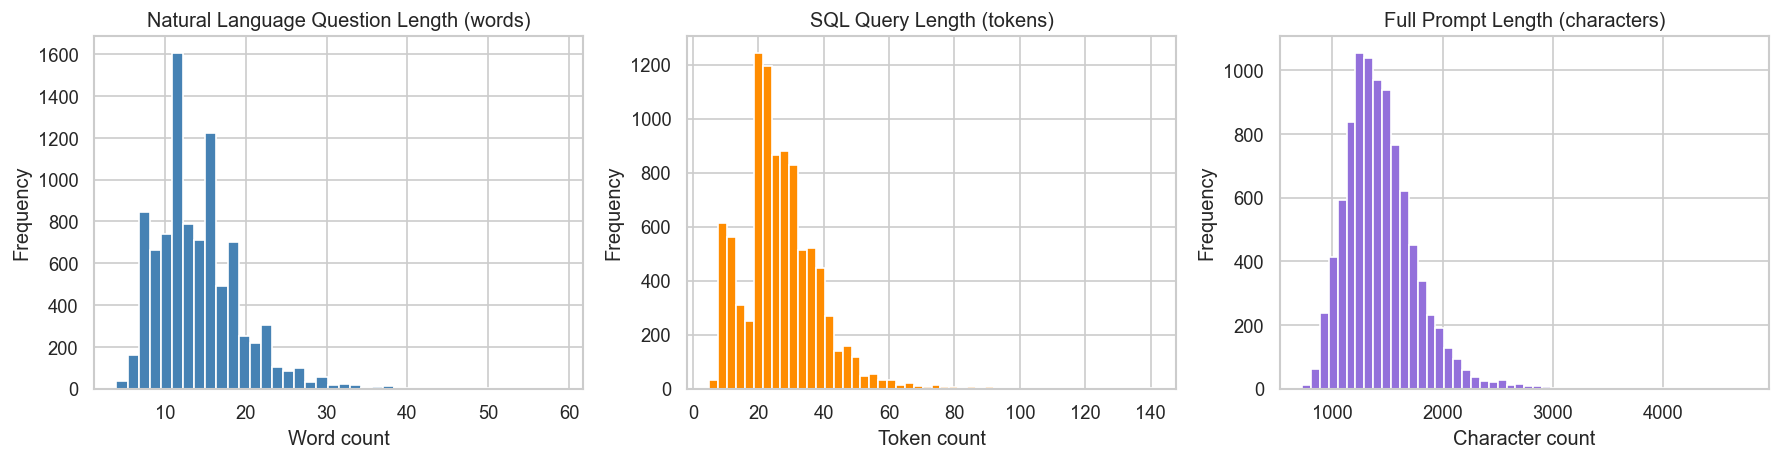

In [37]:
import os
os.makedirs("../figures", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['question_word_len'], bins=40, edgecolor='white', color='steelblue')
axes[0].set_title('Natural Language Question Length (words)')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['sql_token_len'], bins=50, edgecolor='white', color='darkorange')
axes[1].set_title('SQL Query Length (tokens)')
axes[1].set_xlabel('Token count')
axes[1].set_ylabel('Frequency')

axes[2].hist(df['prompt_char_len'], bins=50, edgecolor='white', color='mediumpurple')
axes[2].set_title('Full Prompt Length (characters)')
axes[2].set_xlabel('Character count')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../figures/length_distributions.png', bbox_inches='tight')
plt.show()

## 3.3 SQL Keyword Frequency

For this dataset, learning the frequency of which SQL clause appears most often and least often tells us what kinds of queries the models must learn to generate.

### 3.3.1 Table Representation of Keyword Frequency

In [38]:
SQL_KEYWORDS = [
    'SELECT', 'FROM', 'WHERE', 'JOIN', 'INNER JOIN', 'LEFT JOIN',
    'RIGHT JOIN', 'GROUP BY', 'ORDER BY', 'HAVING', 'LIMIT',
    'DISTINCT', 'COUNT', 'SUM', 'AVG', 'MAX', 'MIN',
    'UNION', 'EXCEPT', 'INTERSECT', 'NOT IN', 'IN', 'LIKE',
    'EXISTS', 'CASE', 'WHEN', 'BETWEEN', 'AS'
]

def keyword_presence(sql_series, keywords):
    """Return a dict of keyword -> count of rows containing that keyword."""
    sql_upper = sql_series.str.upper()
    return {
        kw: int(sql_upper.str.contains(r'\b' + re.escape(kw) + r'\b').sum())
        for kw in keywords
    }

kw_counts = keyword_presence(df['sql'], SQL_KEYWORDS)
kw_df = pd.DataFrame(list(kw_counts.items()), columns=['keyword', 'count'])
kw_df['pct'] = (kw_df['count'] / len(df) * 100).round(1)
kw_df = kw_df.sort_values('count', ascending=False).reset_index(drop=True)
kw_df

,keyword,count,pct
0,SELECT,9198,100.0
1,FROM,9198,100.0
2,WHERE,8084,87.9
3,AS,7327,79.7
4,JOIN,7046,76.6
5,INNER JOIN,7009,76.2
6,COUNT,3167,34.4
7,LIMIT,1749,19.0
8,ORDER BY,1668,18.1
9,SUM,1179,12.8


### 3.3.2 Graphical Represetation of Keyword Frequency

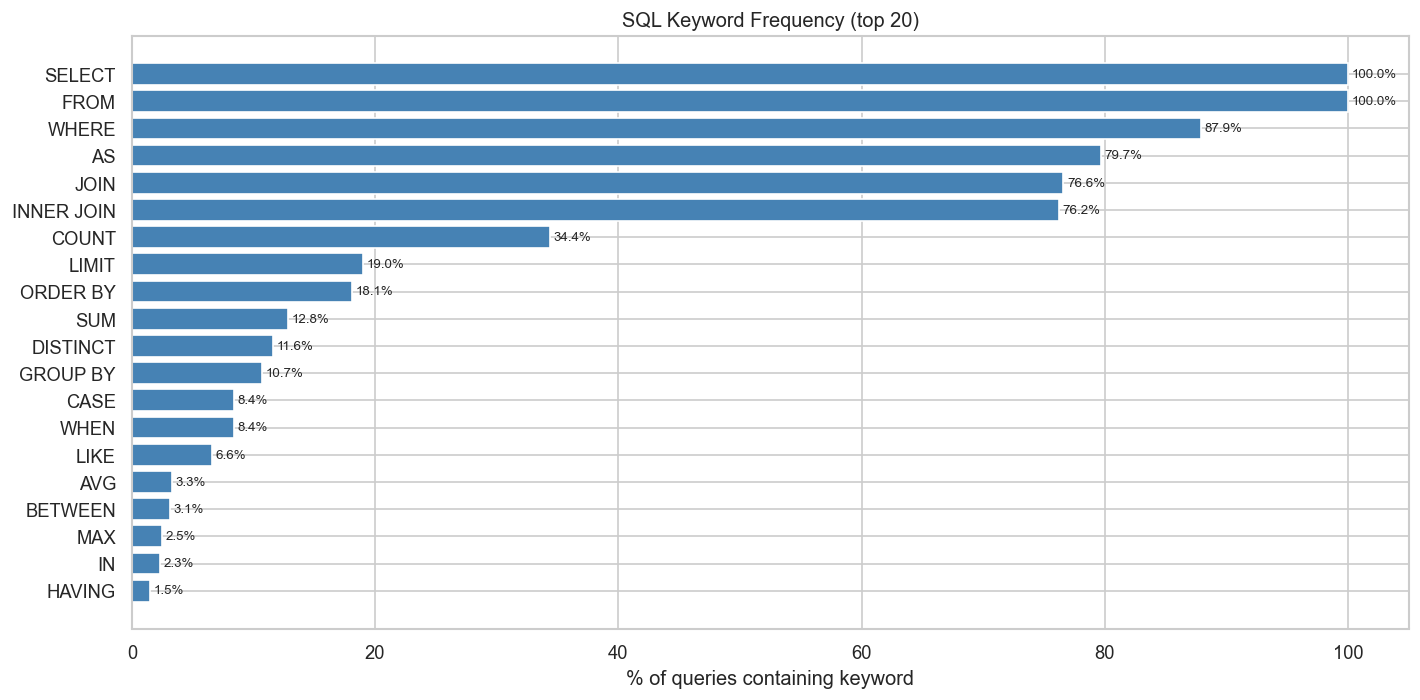

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(kw_df['keyword'][:20], kw_df['pct'][:20], color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('% of queries containing keyword')
ax.set_title('SQL Keyword Frequency (top 20)')
for bar, val in zip(bars, kw_df['pct'][:20]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/keyword_frequency.png', bbox_inches='tight')
plt.show()

## 3.4 Query Complexity Analysis

In terms of complexity of the SQL queries, we can classify each query based on its structure if uses certain constructs:
| Tier | Criteria |
|---|---|
| **Simple** | `SELECT ... FROM ... WHERE` only (no JOINs, no aggregation, no subqueries) |
| **Medium** | Contains at least one `JOIN` OR one aggregation function (`COUNT`, `SUM`, `AVG`, `MAX`, `MIN`) |
| **Complex** | Contains `GROUP BY`, `HAVING`, nested subqueries (`SELECT` inside `WHERE`/`FROM`), or set operators (`UNION`, `EXCEPT`, `INTERSECT`) |

In [40]:
def classify_complexity(sql):
    s = sql.upper()
    has_join        = bool(re.search(r'\bJOIN\b', s))
    has_agg         = bool(re.search(r'\b(COUNT|SUM|AVG|MAX|MIN)\s*\(', s))
    has_group_by    = bool(re.search(r'\bGROUP\s+BY\b', s))
    has_having      = bool(re.search(r'\bHAVING\b', s))
    has_nested      = s.count('SELECT') > 1
    has_set_op      = bool(re.search(r'\b(UNION|EXCEPT|INTERSECT)\b', s))

    if has_group_by or has_having or has_nested or has_set_op:
        return 'Complex'
    elif has_join or has_agg:
        return 'Medium'
    else:
        return 'Simple'

df['complexity'] = df['sql'].apply(classify_complexity)
complexity_counts = df['complexity'].value_counts()
print(complexity_counts)
print()
print((complexity_counts / len(df) * 100).round(1).astype(str) + '%')

complexity
Medium     6778
Complex    1503
Simple      917
Name: count, dtype: int64

complexity
Medium     73.7%
Complex    16.3%
Simple     10.0%
Name: count, dtype: object


C:\Users\Sean Leong\AppData\Local\Temp\ipykernel_17764\3430294238.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_complexity, labels=order, patch_artist=True)


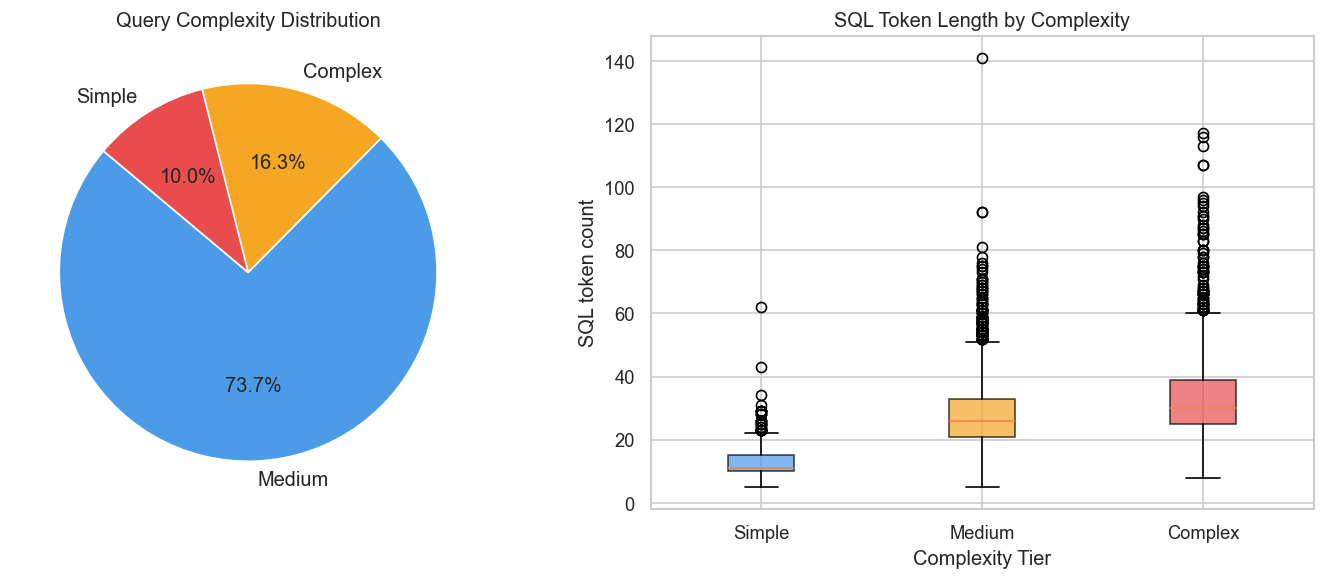

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
colours = ['#4C9BE8', '#F5A623', '#E84C4C']
axes[0].pie(complexity_counts, labels=complexity_counts.index, autopct='%1.1f%%',
            colors=colours, startangle=140, textprops={'fontsize': 12})
axes[0].set_title('Query Complexity Distribution')

# SQL length by complexity
order = ['Simple', 'Medium', 'Complex']
data_by_complexity = [df.loc[df['complexity'] == c, 'sql_token_len'].values for c in order]
bp = axes[1].boxplot(data_by_complexity, labels=order, patch_artist=True)
for patch, colour in zip(bp['boxes'], colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)
axes[1].set_title('SQL Token Length by Complexity')
axes[1].set_xlabel('Complexity Tier')
axes[1].set_ylabel('SQL token count')

plt.tight_layout()
plt.savefig('../figures/complexity_analysis.png', bbox_inches='tight')
plt.show()

## 3.6 JOIN Count Distribution

Since multi-table JOINs are one of the hardest aspects of test-to-SQL. We count how many JOINs appear per query

JOIN count distribution:
join_count
0    2152
1    5167
2    1494
3     311
4      66
5       7
6       1
Name: count, dtype: int64


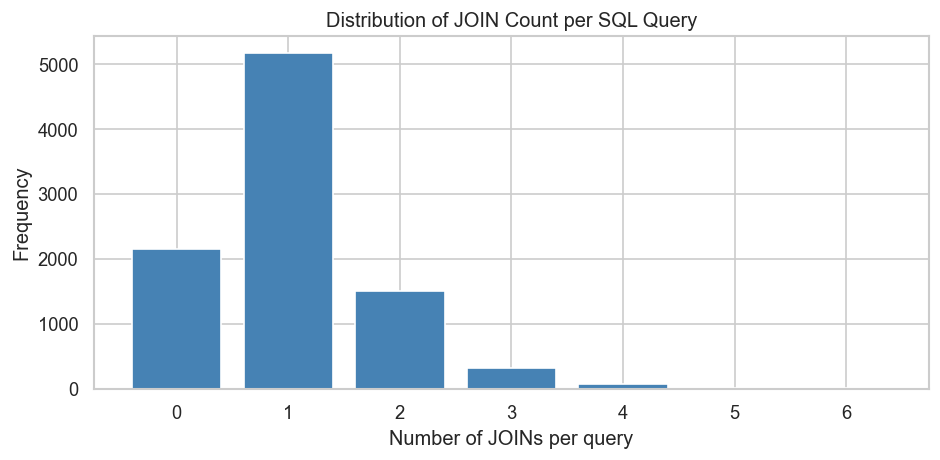

In [42]:
df['join_count'] = df['sql'].str.upper().str.count(r'\bJOIN\b')

join_dist = df['join_count'].value_counts().sort_index()
print("JOIN count distribution:")
print(join_dist)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(join_dist.index.astype(str), join_dist.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of JOINs per query')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of JOIN Count per SQL Query')
plt.tight_layout()
plt.savefig('../figures/join_count_distribution.png', bbox_inches='tight')
plt.show()

## 3.7 Question Length vs SQL Length Correlation

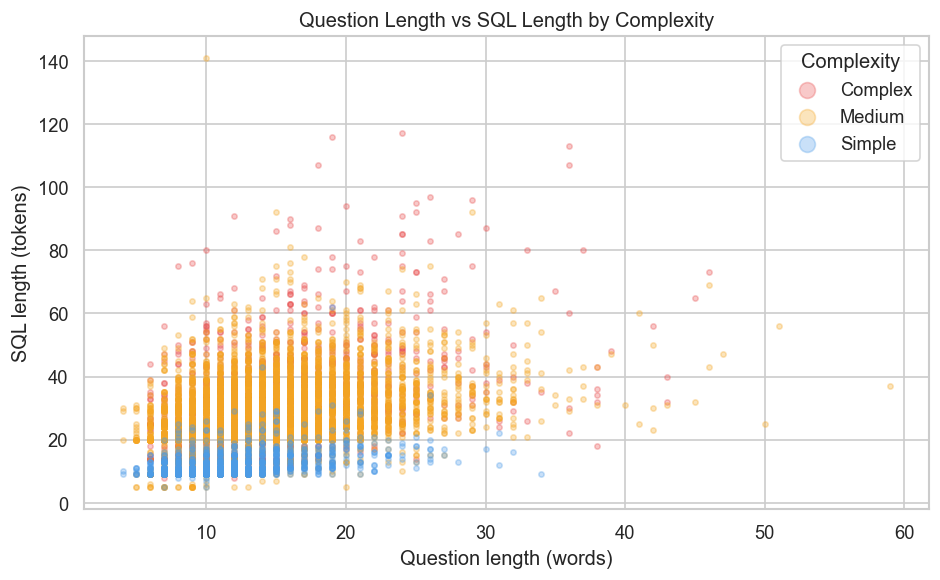

Pearson correlation (question words vs SQL tokens): 0.391


In [43]:
fig, ax = plt.subplots(figsize=(8, 5))

colour_map = {'Simple': '#4C9BE8', 'Medium': '#F5A623', 'Complex': '#E84C4C'}
for tier, grp in df.groupby('complexity'):
    ax.scatter(grp['question_word_len'], grp['sql_token_len'],
               alpha=0.3, s=10, label=tier, color=colour_map[tier])

ax.set_xlabel('Question length (words)')
ax.set_ylabel('SQL length (tokens)')
ax.set_title('Question Length vs SQL Length by Complexity')
ax.legend(title='Complexity', markerscale=3)
plt.tight_layout()
plt.savefig('../figures/q_vs_sql_length.png', bbox_inches='tight')
plt.show()

corr = df[['question_word_len', 'sql_token_len']].corr().iloc[0, 1]
print(f"Pearson correlation (question words vs SQL tokens): {corr:.3f}")

## 3.8 Summary

## 3.9 Export Processed Dataset

In [44]:
from sklearn.model_selection import train_test_split

# Ensure derived columns exist (re-compute in case cells were run out of order)
df["sql_token_len"] = df["sql"].str.split().str.len()
df["join_count"]    = df["sql"].str.upper().str.count(r"\bJOIN\b")
df["complexity"]    = df["sql"].apply(classify_complexity)

# Fixed train/test split (80/20), stratified on complexity so both splits
# have the same Simple/Medium/Complex ratio. Seed is fixed so every model
# notebook gets the identical split — required for a fair comparison.
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["complexity"]
)
df["split"] = "train"
df.loc[test_df.index, "split"] = "test"

# Select only the columns model notebooks need
export_cols = ["prompt", "question", "response", "sql",
               "complexity", "join_count", "sql_token_len", "split"]
df[export_cols].to_csv("../data/processed.csv", index=False)

print(f"Saved {len(df):,} rows to ../data/processed.csv")
print(f"Train: {(df['split']=='train').sum():,} | Test: {(df['split']=='test').sum():,}")
print()
print("Split x Complexity breakdown:")
print(df.groupby(["split", "complexity"]).size().unstack())

Saved 9,198 rows to ../data/processed.csv
Train: 7,358 | Test: 1,840

Split x Complexity breakdown:
complexity  Complex  Medium  Simple
split                              
test            301    1356     183
train          1202    5422     734
